In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
sim_address = 'torque_vs_h.csv'
sim_df = pd.read_csv(sim_address, comment='#')

sim_df = sim_df[['h_m', 'T_per_rpm_Nm_per_rpm']]

# Rename columns for clarity
sim_df.rename(columns={'h_m': 'Height_um', 'T_per_rpm_Nm_per_rpm': 'Rotational_Drag_uNm_per_rpm'}, inplace=True)
# Update units from meters to micrometers for height
sim_df['Height_um'] = sim_df['Height_um'] * 1e6
# Update units from Nm-per-rpm to microNm-per-rpm for rotational drag
sim_df['Rotational_Drag_uNm_per_rpm'] = sim_df['Rotational_Drag_uNm_per_rpm'] * 1e6

sim_df.head()

,Height_um,Rotational_Drag_uNm_per_rpm
0,10.000000,261.377322
1,11.110798,260.711486
2,12.344983,259.976553
3,13.716262,259.165892
4,15.239861,258.272353


In [34]:
exp_address = '../dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv'
exp_df = pd.read_csv(exp_address)
# Remove Extra Columns
exp_df = exp_df[['cell', 'Z_Height_mm', 'Rotational_Drag']]

# Rotational_Drag in CSV is in % of max (0-100 scale).
# Convert: % -> fraction (/100) -> Nm (* max in Nm) -> microNm (* 1e6)
max_rotational_drag_dyne_cm = 7187.0  # Dyne-Centimeter
max_rotational_drag = max_rotational_drag_dyne_cm * 1e-7  # Convert to Nm
exp_df['Rotational_Drag'] = (exp_df['Rotational_Drag'] / 100) * max_rotational_drag * 1e6  # microNm-per-rpm

# Convert Z_Height from mm to micrometers
exp_df['Z_Height_mm'] = exp_df['Z_Height_mm'] * 1000
exp_df.rename(columns={'Z_Height_mm': 'Height_um', 'Rotational_Drag': 'Rotational_Drag_uNm_per_rpm'}, inplace=True)

exp_df.head()


,cell,Height_um,Rotational_Drag_uNm_per_rpm
0,1,-65740.0,153.248954
1,1,-65760.0,157.450582
2,1,-65780.0,162.094491
3,1,-65800.0,165.909128
4,1,-65820.0,169.281491


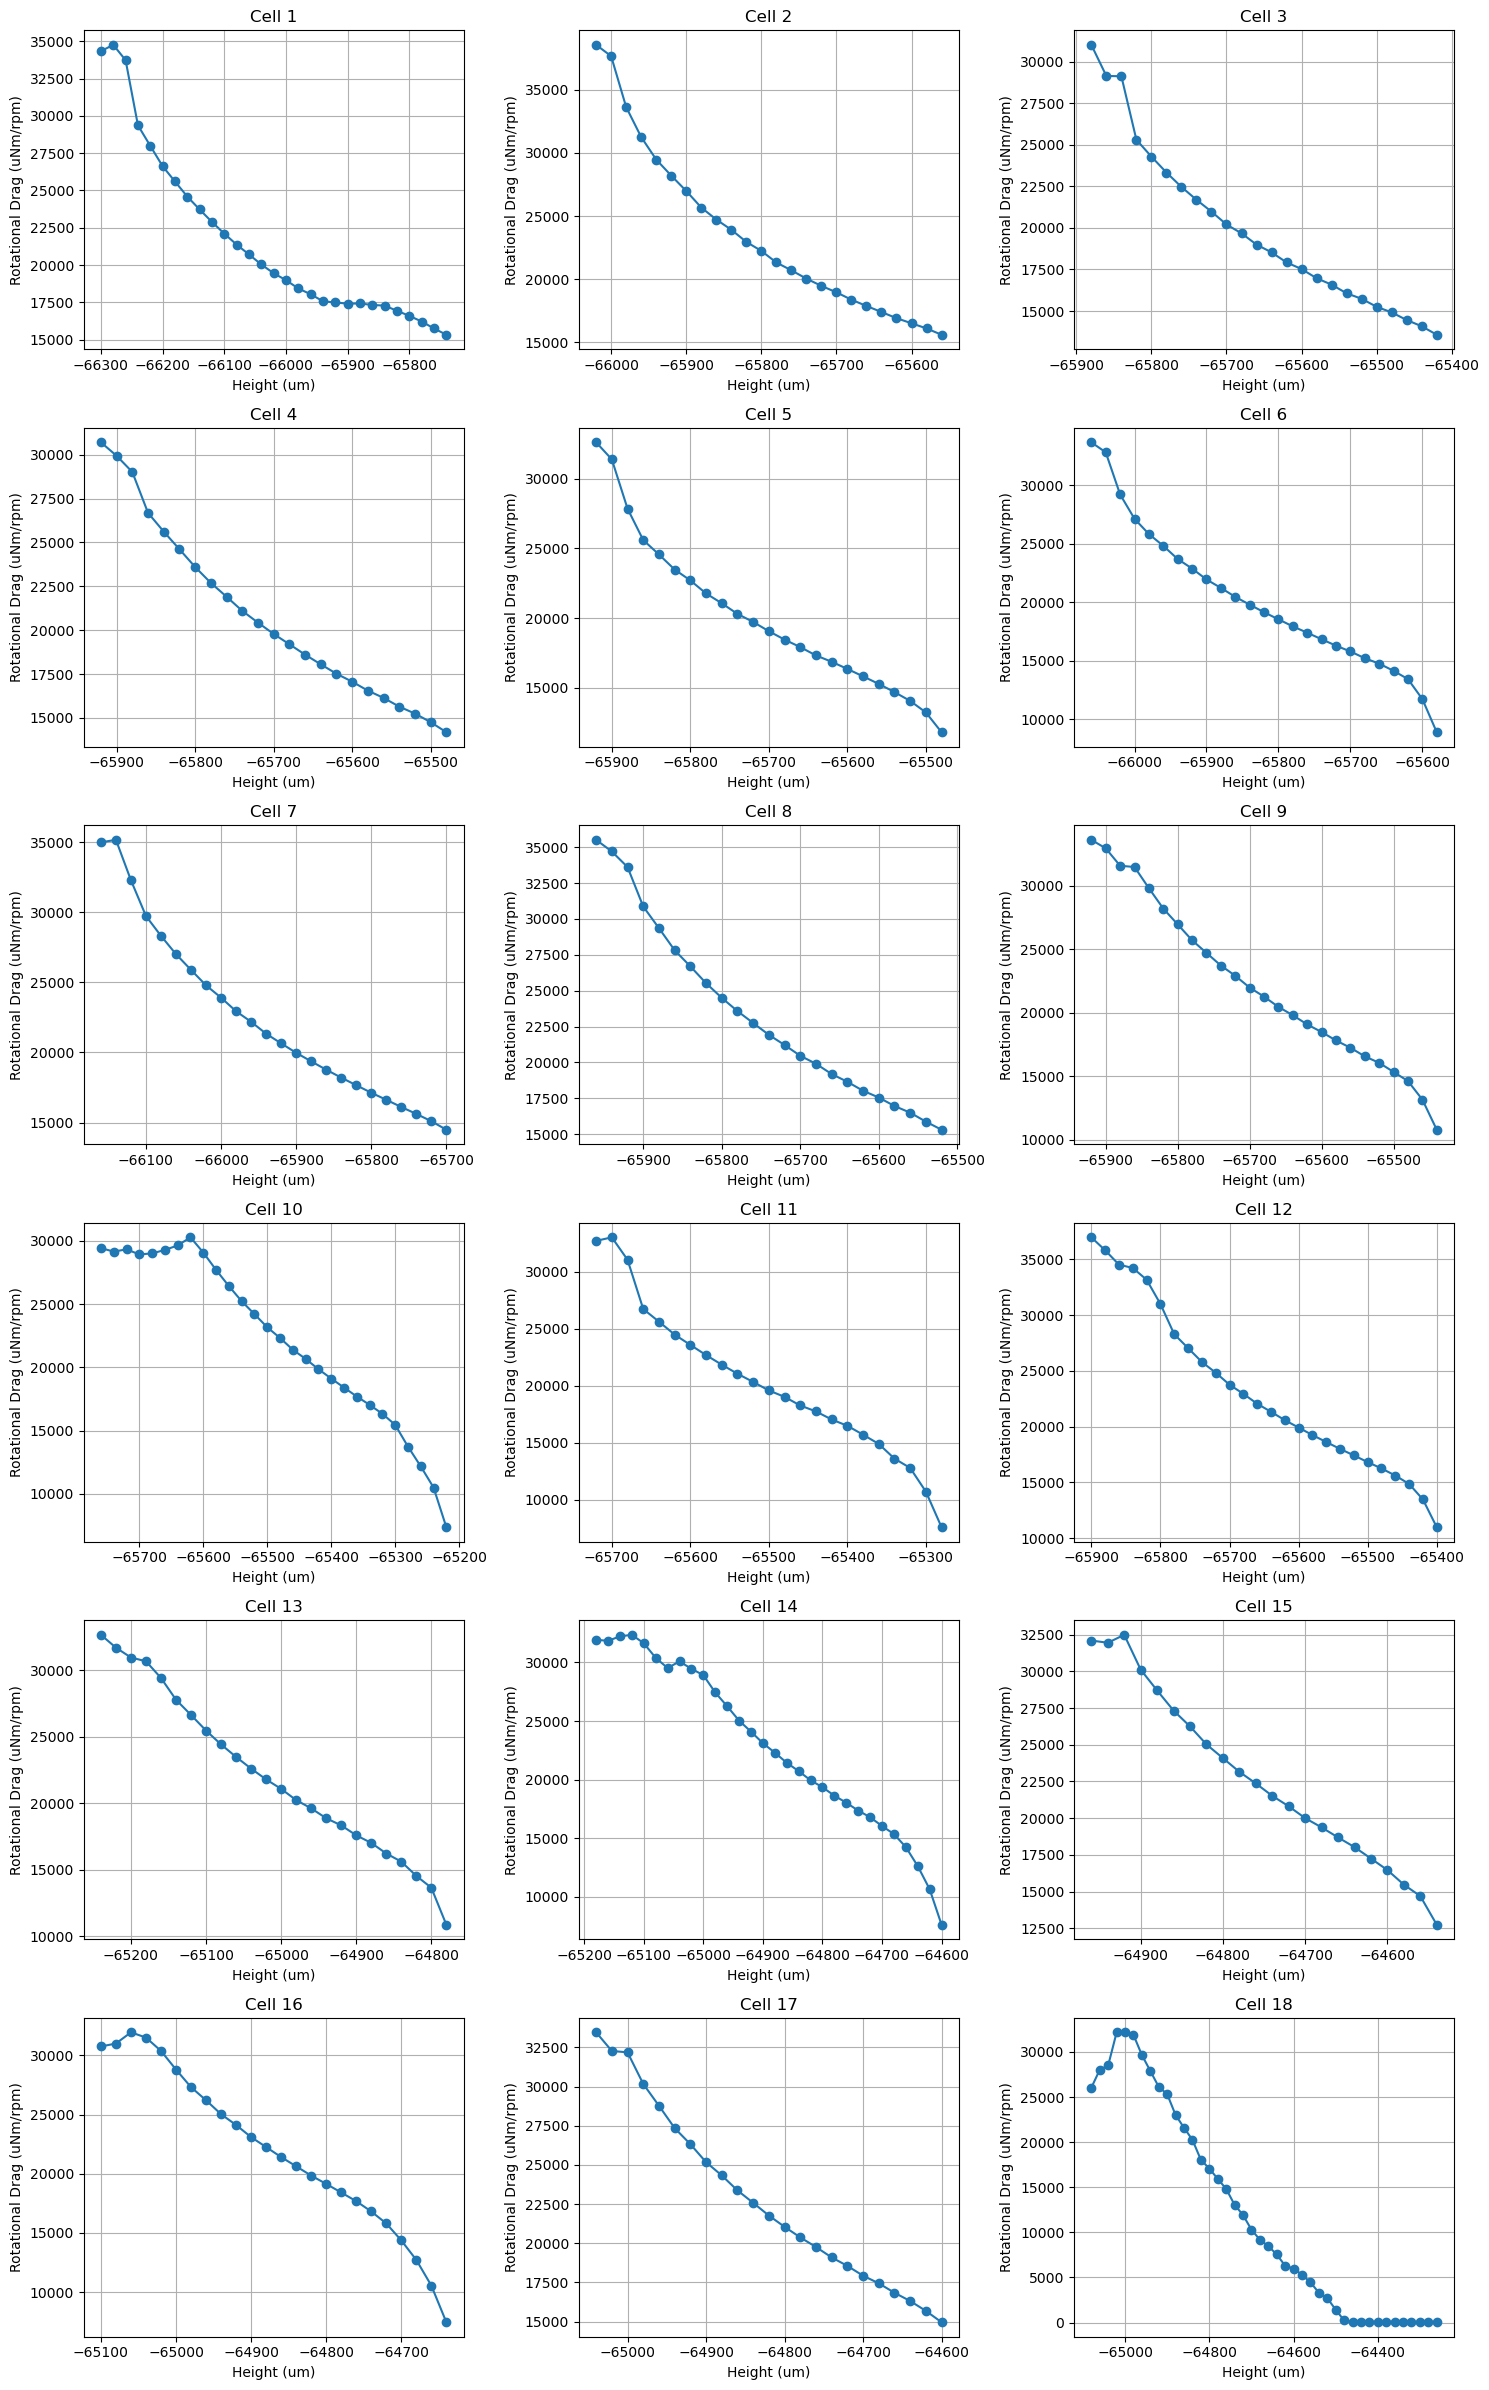

In [21]:
cells = sorted(exp_df['cell'].unique())
n = len(cells)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for ax, cell in zip(axes.flat, cells):
    sub = exp_df[exp_df['cell'] == cell]
    ax.plot(sub['Height_um'], sub['Rotational_Drag_uNm_per_rpm'], marker='o', linestyle='-')
    ax.set_title(f'Cell {cell}')
    ax.set_xlabel('Height (um)')
    ax.set_ylabel('Rotational Drag (uNm/rpm)')
    ax.grid(True)

# Hide any unused subplots
for ax in axes.flat[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()


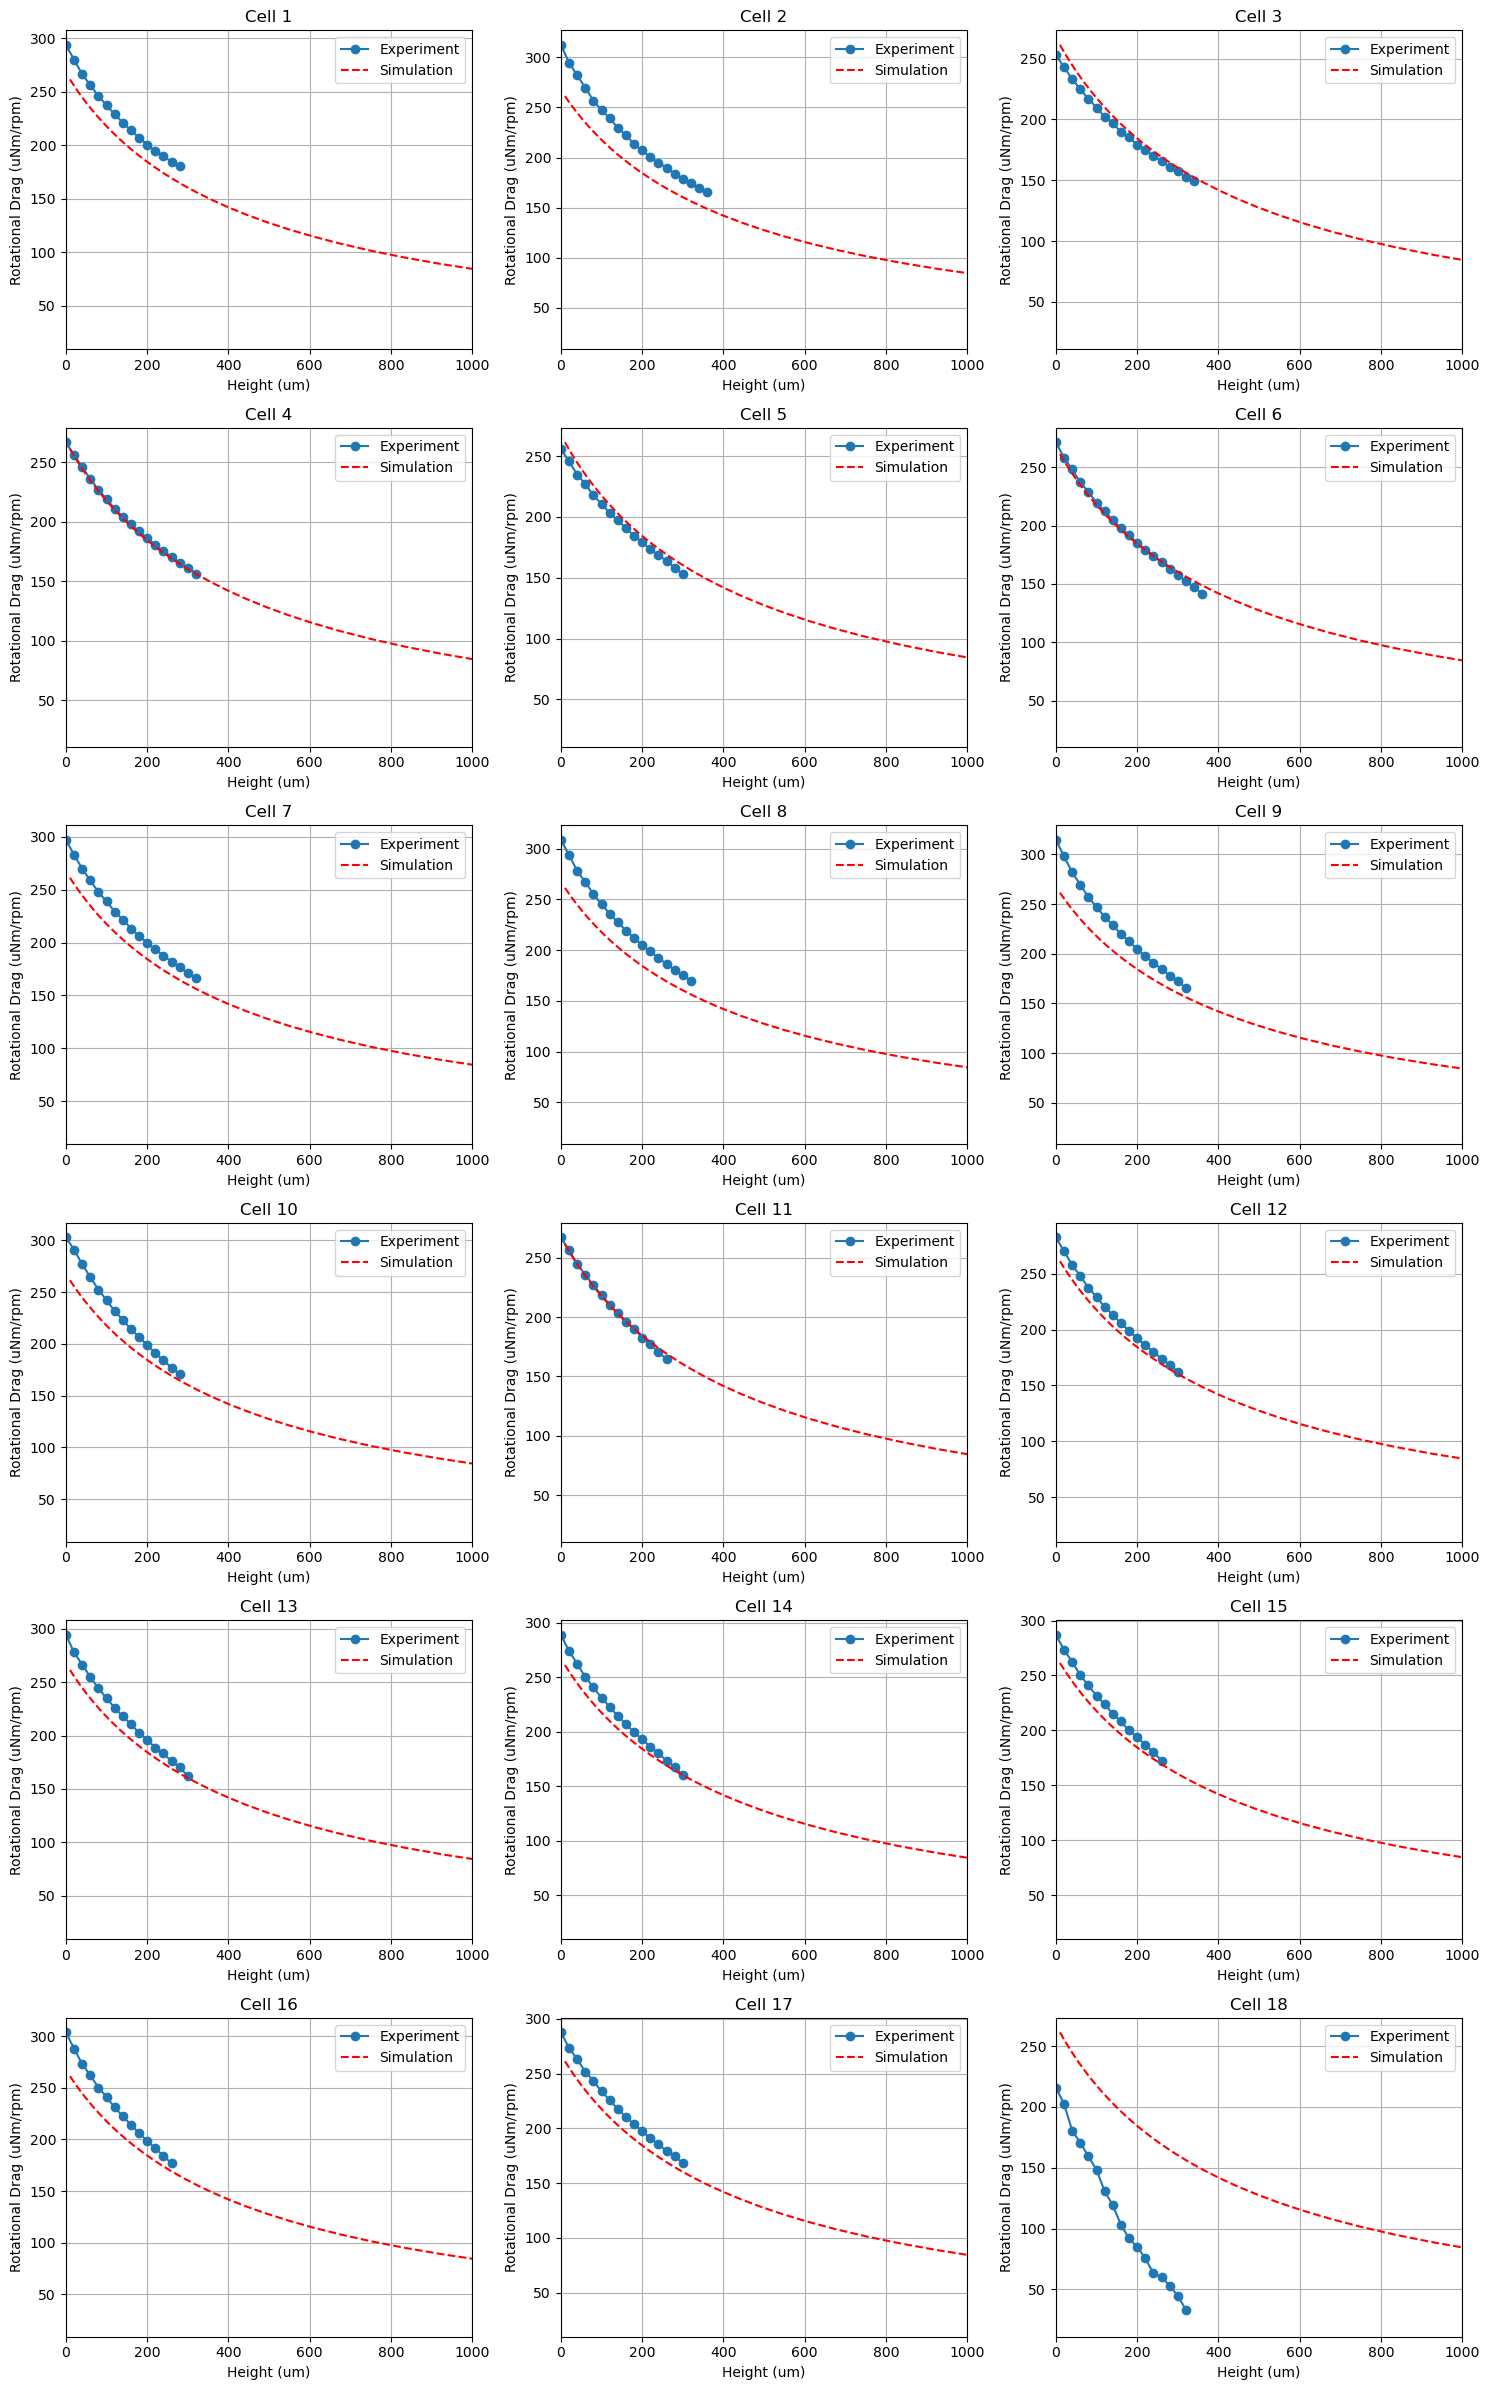

In [37]:
trim_ranges = {
    1: (-66240, -65960),
    2: (-65960, -65600),
    3: (-65820, -65460),
    4: (-65860, -65520),
    5: (-65860, -65560),
    6: (-66000, -65640),
    7: (-66100, -65780),
    8: (-65900, -65580),
    9: (-65860, -65540),
    10: (-65620, -65320),
    11: (-65660, -65380),
    12: (-65780, -65460),
    13: (-65160, -64860),
    14: (-65000, -64700),
    15: (-64900, -64600),
    16: (-65020, -64760),
    17: (-64980, -64660),
    18: (-64860, -64540),
}

parts = []
for cell_num, (lo, hi) in trim_ranges.items():
    sub = exp_df[(exp_df['cell'] == cell_num) &
                 (exp_df['Height_um'] >= lo) &
                 (exp_df['Height_um'] <= hi)].copy()
    parts.append(sub)

exp_df_trimmed = pd.concat(parts, ignore_index=True)

# Shift each cell's curve so that its minimum height starts at 0
exp_df_trimmed['Height_um'] = exp_df_trimmed.groupby('cell')['Height_um'].transform(lambda x: x - x.min())

# Plot trimmed and shifted data, overlay simulated results
cells = sorted(exp_df_trimmed['cell'].unique())
n = len(cells)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for ax, cell in zip(axes.flat, cells):
    sub = exp_df_trimmed[exp_df_trimmed['cell'] == cell]
    ax.plot(sub['Height_um'], sub['Rotational_Drag_uNm_per_rpm'], marker='o', linestyle='-', label='Experiment')
    ax.plot(sim_df['Height_um'], sim_df['Rotational_Drag_uNm_per_rpm'], linestyle='--', color='red', label='Simulation')
    ax.set_title(f'Cell {cell}')
    ax.set_xlabel('Height (um)')
    ax.set_ylabel('Rotational Drag (uNm/rpm)')
    ax.grid(True)
    ax.set_xlim(0, 1000)  # Set x-axis limits for better comparison
    ax.legend()

for ax in axes.flat[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()


Fit quality per cell (sorted by RMSE, lower = better):
 cell  n_points      RMSE       MAE        R2
    4        16  1.281319  1.220474  0.998186
   11        13  1.820231  1.237501  0.995784
    6        18  2.908576  2.355463  0.992915
    3        17  6.946731  6.290432  0.939327
    5        15  6.960684  6.790444  0.937457
   12        15  9.724504  9.024642  0.910644
   14        15 11.627890 10.377272  0.884073
   15        13 12.592571 11.865447  0.832541
   17        15 14.344215 14.011314  0.798887
   13        15 14.676414 13.451097  0.821643
    7        16 18.318450 17.577809  0.729616
    1        14 18.473010 18.279669  0.633220
   16        13 20.890779 19.618052  0.618633
   10        14 21.469698 19.559112  0.658181
    8        16 24.462700 23.465620  0.562277
    9        16 25.379951 23.652207  0.582054
    2        18 26.017484 25.083090  0.552692
   18        16 92.835789 90.375768 -2.293775

Best-fitting cell: 4 (RMSE = 1.2813 uNm/rpm)


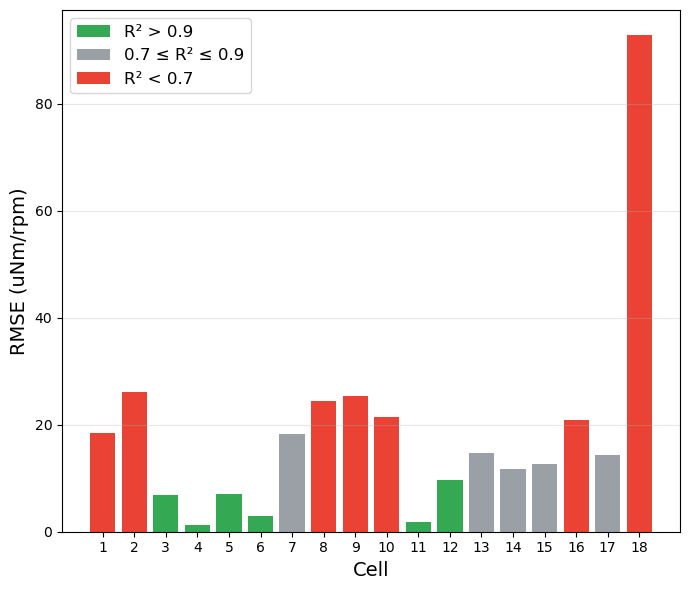

In [42]:
# Find the experimental cell that best fits the simulation curve.
# Strategy: for each cell, interpolate the simulation at the experimental Height_um
# values (within the simulation's height range), then compute RMSE.

sim_sorted = sim_df.sort_values('Height_um').reset_index(drop=True)
sim_h = sim_sorted['Height_um'].values
sim_t = sim_sorted['Rotational_Drag_uNm_per_rpm'].values
sim_h_min, sim_h_max = sim_h.min(), sim_h.max()

scores = []
for cell_num in sorted(exp_df_trimmed['cell'].unique()):
    sub = exp_df_trimmed[exp_df_trimmed['cell'] == cell_num]
    # keep only points within the simulation's height range to avoid extrapolation
    mask = (sub['Height_um'] >= sim_h_min) & (sub['Height_um'] <= sim_h_max)
    sub_in = sub[mask]
    if len(sub_in) < 2:
        continue
    sim_interp = np.interp(sub_in['Height_um'].values, sim_h, sim_t)
    exp_vals = sub_in['Rotational_Drag_uNm_per_rpm'].values
    rmse = float(np.sqrt(np.mean((exp_vals - sim_interp) ** 2)))
    mae = float(np.mean(np.abs(exp_vals - sim_interp)))
    # R^2 vs simulation as the "model"
    ss_res = float(np.sum((exp_vals - sim_interp) ** 2))
    ss_tot = float(np.sum((exp_vals - exp_vals.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    scores.append({'cell': int(cell_num), 'n_points': int(len(sub_in)),
                   'RMSE': rmse, 'MAE': mae, 'R2': r2})

scores_df = pd.DataFrame(scores).sort_values('RMSE').reset_index(drop=True)
print("Fit quality per cell (sorted by RMSE, lower = better):")
print(scores_df.to_string(index=False))

best_cell = int(scores_df.iloc[0]['cell'])
print(f"\nBest-fitting cell: {best_cell} (RMSE = {scores_df.iloc[0]['RMSE']:.4f} uNm/rpm)")

# Bar chart of RMSE per cell, colored by R^2 quality (Google brand colors)
GOOGLE_GREEN = '#34A853'
GOOGLE_GRAY = '#9AA0A6'
GOOGLE_RED = '#EA4335'

def r2_color(r2):
    if r2 > 0.9:
        return GOOGLE_GREEN
    elif r2 >= 0.7:
        return GOOGLE_GRAY
    else:
        return GOOGLE_RED

order = scores_df.sort_values('cell')
colors = [r2_color(r2) for r2 in order['R2']]

fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(order['cell'].astype(str), order['RMSE'], color=colors)
ax.set_xlabel('Cell', fontsize=14)
ax.set_ylabel('RMSE (uNm/rpm)', fontsize=14)
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=GOOGLE_GREEN, label='R² > 0.9'),
    Patch(facecolor=GOOGLE_GRAY, label='0.7 ≤ R² ≤ 0.9'),
    Patch(facecolor=GOOGLE_RED, label='R² < 0.7'),
], loc='best', fontsize=12)

fig.tight_layout()
plt.show()
